# Analyzing Crime Patterns in Seattle to Inform Urban Mobility and Public Safety


*by Justin Kim*

**Dataset:** [Seattle Police Department Crime Incident Data (2008–Present)](https://data.seattle.gov/Public-Safety/SPD-Crime-Data-2008-Present/tazs-3rd5/about_data)
(Dataset downloaded on February 10, 2026)



## 0. Setup

In [13]:
# Import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Overview

### 1.1 Load Data

In [65]:
# Load the crime dataset into a pandas DataFrame
df = pd.read_csv('data/SPD_Crime_Data__2008-Present_20260210.csv')

# Load the stops dataset into a pandas DataFrame
stops_df = pd.read_csv('data/stops.txt')

### 1.2 Initial Inspection of Crime Data

In [68]:
# Display the first few rows of the crime DataFrame to verify it loaded correctly
df.head()

,Report Number,Report DateTime,Offense ID,Offense Date,NIBRS Group AB,NIBRS Crime Against Category,Offense Sub Category,Shooting Type Group,Block Address,Latitude,Longitude,Beat,Precinct,Sector,Neighborhood,Reporting Area,Offense Category,NIBRS Offense Code Description,NIBRS_offense_code
0,2015-190826,2015 Jun 08 09:39:00 AM,7655587915,2015 May 24 02:00:00 PM,A,PROPERTY,LARCENY-THEFT,-,26XX BLOCK OF W MARINA PL,47.63103937,-122.391970808268,Q1,West,Q,-,7089,PROPERTY CRIME,All Other Larceny,23H
1,2008-479747,2008 Dec 28 10:14:00 PM,7639775836,2008 Dec 28 10:14:00 PM,A,PROPERTY,LARCENY-THEFT,-,-,-1.0,-1.0,D2,West,D,-,3700,PROPERTY CRIME,Theft From Motor Vehicle,23F
2,2014-158003,2014 May 20 05:42:00 PM,7668842409,2014 May 20 05:42:00 PM,A,PROPERTY,LARCENY-THEFT,-,-,-1.0,-1.0,F3,Southwest,F,-,4197,PROPERTY CRIME,All Other Larceny,23H
3,2012-380870,2012 Nov 06 09:40:00 AM,7649760707,2012 Nov 04 08:00:00 PM,A,PROPERTY,BURGLARY,-,30XX BLOCK OF 29TH AVE W,47.64773751,-122.394242455682,Q1,West,Q,-,7024,PROPERTY CRIME,Burglary/Breaking & Entering,220
4,2014-041879,2014 Feb 07 10:47:00 PM,7628705100,2014 Feb 07 09:00:00 PM,A,PROPERTY,LARCENY-THEFT,-,7XX BLOCK OF S DEARBORN ST,47.59583224,-122.323111156883,K3,West,K,-,1502,PROPERTY CRIME,Theft From Motor Vehicle,23F


In [69]:
# Display the column names to understand the structure of the dataset
df.columns

Index(['Report Number', 'Report DateTime', 'Offense ID', 'Offense Date',
       'NIBRS Group AB', 'NIBRS Crime Against Category',
       'Offense Sub Category', 'Shooting Type Group', 'Block Address',
       'Latitude', 'Longitude', 'Beat', 'Precinct', 'Sector', 'Neighborhood',
       'Reporting Area', 'Offense Category', 'NIBRS Offense Code Description',
       'NIBRS_offense_code'],
      dtype='object')

In [70]:
# Display shape of the DataFrame to understand how many rows and columns it contains
df.shape

(1514383, 19)

In [71]:
# Display summary statistics of the DataFrame to understand the distribution of numerical columns
df.describe()

,Offense ID
count,1.514383e+06
mean,1.903475e+10
std,1.899956e+10
min,7.624429e+09
25%,7.659382e+09
50%,7.689669e+09
75%,2.640175e+10
max,6.849260e+10


In [72]:
# Display information about the DataFrame to understand data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1514383 entries, 0 to 1514382
Data columns (total 19 columns):
 #   Column                          Non-Null Count    Dtype 
---  ------                          --------------    ----- 
 0   Report Number                   1514383 non-null  object
 1   Report DateTime                 1514383 non-null  object
 2   Offense ID                      1514383 non-null  int64 
 3   Offense Date                    1514383 non-null  object
 4   NIBRS Group AB                  1514383 non-null  object
 5   NIBRS Crime Against Category    1514383 non-null  object
 6   Offense Sub Category            1514383 non-null  object
 7   Shooting Type Group             1514383 non-null  object
 8   Block Address                   1514383 non-null  object
 9   Latitude                        1514383 non-null  object
 10  Longitude                       1514383 non-null  object
 11  Beat                            1514383 non-null  object
 12  Precinct      

**1.2.1 Structural Summary of the Dataset**

The dataset contains 1,514,383 crime incident records and 19 variables, representing reported crime events in Seattle over multiple years. With a memory footprint of approximately 219 MB, the dataset is sufficiently large to support meaningful exploratory analysis of temporal and geographic safety patterns.

**Data Composition**

Each row corresponds to a single reported crime incident. The dataset can be grouped into the following structural components:

- **Identifier variables:** `Report Number` and `Offense ID` function as unique identifiers and are not used directly in analysis.

- **Temporal variables:** `Report DateTime` and `Offense Date` capture when incidents occurred and were reported. These fields are converted into datetime format to enable analysis of trends across time (e.g., hour of day, day of week, seasonal patterns).

- **Spatial variables:** `Latitude`, `Longitude`, `Precinct`, `Sector`, `Beat`, `Neighborhood`, and `Reporting Area` provide geographic context for each incident. These variables are critical for identifying spatial patterns and understanding how crime distribution varies across neighborhoods.

- **Crime classification variables:** `Offense Category`, `Offense Sub Category`, `NIBRS Crime Against Category`, `NIBRS Offense Code Description`, and `NIBRS_offense_code` describe the nature of each incident at varying levels of granularity, enabling analysis of crime types and their distribution.

**Data Type Characteristics**

The dataset is predominantly categorical, with most variables stored as object types. This structure supports grouping, aggregation, and pattern analysis across time, location, and crime categories.

**Data Quality Considerations**

Although no explicit null values are present, placeholder values such as `-1.0` in geographic coordinates and "-" in categorical fields indicate implicit missing data. These inconsistencies must be identified and handled during preprocessing to ensure accurate and reliable analysis of safety patterns.

### 1.3 Initial Inspection of GTFS Stops Data

In [66]:
# Display first few rows
stops_df.head()

,stop_id,stop_code,stop_name,tts_stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,stop_timezone,wheelchair_boarding
0,100,100,1st Ave & Spring St,First Avenue and Spring Street,NaN,47.605137,-122.336533,21,NaN,0,NaN,America/Los_Angeles,1
1,10005,10005,40th Ave NE & NE 51st St,40th Avenue Northeast and Northeast 51st Street,NaN,47.665886,-122.284897,1,NaN,0,NaN,America/Los_Angeles,1
2,10010,10010,NE 55th St & 39th Ave NE,Northeast 55th Street and 39th Avenue Northeast,NaN,47.668579,-122.285667,1,NaN,0,NaN,America/Los_Angeles,1
3,10020,10020,NE 55th St & 37th Ave NE,Northeast 55th Street and 37th Avenue Northeast,NaN,47.668579,-122.288300,1,NaN,0,NaN,America/Los_Angeles,1
4,10030,10030,NE 55th St & 35th Ave NE,Northeast 55th Street and 35th Avenue Northeast,NaN,47.668579,-122.290512,1,NaN,0,NaN,America/Los_Angeles,1


In [67]:
# Display column names of stops_df
stops_df.columns

Index(['stop_id', 'stop_code', 'stop_name', 'tts_stop_name', 'stop_desc',
       'stop_lat', 'stop_lon', 'zone_id', 'stop_url', 'location_type',
       'parent_station', 'stop_timezone', 'wheelchair_boarding'],
      dtype='object')

In [73]:
# Display shape of stops_df
stops_df.shape

(6363, 13)

In [74]:
# Display summary statistics of stops_df
stops_df.describe()

,stop_id,stop_code,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,wheelchair_boarding
count,6363.000000,6363.000000,0.0,6363.000000,6363.000000,6363.000000,0.0,6363.0,0.0,6363.000000
mean,48795.300644,48795.300644,NaN,47.565806,-122.258251,14.667295,NaN,0.0,NaN,1.024202
std,25352.297855,25352.297855,NaN,0.130222,0.103719,12.002440,NaN,0.0,NaN,0.200703
min,100.000000,100.000000,NaN,47.189117,-122.506622,1.000000,NaN,0.0,NaN,0.000000
25%,27250.000000,27250.000000,NaN,47.480305,-122.334499,1.000000,NaN,0.0,NaN,1.000000
50%,55371.000000,55371.000000,NaN,47.589043,-122.290390,19.000000,NaN,0.0,NaN,1.000000
75%,70245.000000,70245.000000,NaN,47.668379,-122.190506,24.000000,NaN,0.0,NaN,1.000000
max,99997.000000,99997.000000,NaN,47.865589,-121.785835,79.000000,NaN,0.0,NaN,2.000000


In [75]:
# Display information about the DataFrame to understand data types and non-null counts
stops_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6363 entries, 0 to 6362
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   stop_id              6363 non-null   int64  
 1   stop_code            6363 non-null   int64  
 2   stop_name            6363 non-null   object 
 3   tts_stop_name        6363 non-null   object 
 4   stop_desc            0 non-null      float64
 5   stop_lat             6363 non-null   float64
 6   stop_lon             6363 non-null   float64
 7   zone_id              6363 non-null   int64  
 8   stop_url             0 non-null      float64
 9   location_type        6363 non-null   int64  
 10  parent_station       0 non-null      float64
 11  stop_timezone        6363 non-null   object 
 12  wheelchair_boarding  6363 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 646.4+ KB


**1.3.1 Summary of GTFS Stops Data**  

The initial inspection of the King County Metro GTFS stops dataset reveals a high-quality, production-ready spatial dataset. Key observations include:

* **Dataset Volume:** The dataset contains **6,363 transit stops**, providing a dense network for proximity analysis against crime incidents.
* **Spatial Integrity:** Coordinate ranges (**Latitude:** 47.19 to 47.87; **Longitude:** -122.51 to -121.79) are perfectly consistent with the greater Seattle/King County geographic bounds. This ensures the data will align correctly with the cleaned crime dataset.
* **Data Cleanliness:** Key spatial fields (`stop_lat`, `stop_lon`) and identifiers (`stop_id`) contain **zero null values**, a significant improvement over the raw crime data. 
* **Sparse Fields:** Several columns (`stop_desc`, `stop_url`, `parent_station`) are entirely empty. These will be excluded from the final analysis to minimize dimensionality without loss of insight.
* **Accessibility Data:** Preliminary stats on `wheelchair_boarding` (mean ≈ 1.02) suggest that the vast majority of stops in this subset are coded for accessibility, which serves as a valuable secondary variable for equity-focused analysis.

**Conclusion:** The GTFS data is validated and ready for a spatial join. The high fidelity of these coordinates provides a reliable "ground truth" for identifying transit-adjacent crime hotspots and evaluating the relationship between infrastructure and public safety.

## 2. Data Preprocessing

### 2.1 Missing & Invalid Values

**2.1.1 Implicit Missing Values – Geographic Coordinates**


Although no explicit null values were detected during initial inspection, further validation of the geographic fields revealed data quality issues. After converting `Latitude` and `Longitude` to numeric format, some values were coerced to `NaN`, indicating non-numeric or improperly formatted entries. In addition, certain records contained placeholder values of `-1.0`, which represent missing or invalid geographic coordinates.

In total, approximately 34.80% of the dataset (390,989 records) contained either missing or invalid coordinate values and were excluded from further analysis.

Because this analysis focuses on identifying geographic safety patterns across Seattle, accurate location data is essential. Records without valid coordinates cannot be reliably associated with neighborhoods or used to assess how crime distribution may impact transit access, rider behavior, or perceived safety.

Removing these records ensures that subsequent analysis reflects true spatial patterns rather than artifacts of incomplete or erroneous data. While this reduces the dataset size, it improves the reliability and interpretability of the insights derived.

In [20]:
# Confirm the percentage of missing values in each column (should be 0 based on the info() output)
(df.isna().sum() / len(df)) * 100

Report Number                     0.0
Report DateTime                   0.0
Offense ID                        0.0
Offense Date                      0.0
NIBRS Group AB                    0.0
NIBRS Crime Against Category      0.0
Offense Sub Category              0.0
Shooting Type Group               0.0
Block Address                     0.0
Latitude                          0.0
Longitude                         0.0
Beat                              0.0
Precinct                          0.0
Sector                            0.0
Neighborhood                      0.0
Reporting Area                    0.0
Offense Category                  0.0
NIBRS Offense Code Description    0.0
NIBRS_offense_code                0.0
dtype: float64

In [21]:
# Convert 'Latitude' and 'Longitude' columns to numeric, coercing errors to NaN
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
# print how many rows have missing values in 'Latitude' and 'Longitude' after conversion
print(f"Missing values in Latitude: {df['Latitude'].isna().sum()}")
print(f"Missing values in Longitude: {df['Longitude'].isna().sum()}")
#df = df.dropna(subset=["Latitude", "Longitude"])

# Check for invalid coordinates (Latitude or Longitude equal to -1.0)
invalid_coords = ((df['Latitude'] == -1.0) | (df['Longitude'] == -1.0))
print(f"Invalid coordinates: {invalid_coords.sum()}")

invalid_mask = (
    df['Latitude'].isna() |
    df['Longitude'].isna() |
    (df['Latitude'] == -1.0) |
    (df['Longitude'] == -1.0)
)

print(f"Total invalid rows: {invalid_mask.sum()}")


Missing values in Latitude: 219217
Missing values in Longitude: 219217
Invalid coordinates: 171772
Total invalid rows: 390989


In [22]:
# Calculate and print percentage of invalid rows
total_rows = len(df)
invalid_rows = invalid_mask.sum()
invalid_percentage = (invalid_rows / total_rows) * 100
print(f"Percentage of invalid rows: {invalid_percentage:.2f}%")

# Remove rows with missing or placeholder coordinates
df = df.loc[~invalid_mask].copy()

# Verify remaining shape
print(df.shape)

Percentage of invalid rows: 25.82%
(1123394, 19)


In [23]:
# Drop records lacking valid coordinates
df = df[~invalid_coords].copy()

# Check shape of the DataFrame after dropping invalid coordinates
df.shape

/var/folders/64/877d0whj5dq1cx44pnly09680000gn/T/ipykernel_71837/2682844688.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[~invalid_coords].copy()


(1123394, 19)

**2.1.2 Geographic Boundary Validation**

In addition to placeholder values (-1.0), a small number of records contained geographic coordinates outside realistic bounds for Seattle. To address this, a bounding box was defined using approximate latitude (47 to 48) and longitude (-123 to -121) ranges.

A total of 542 records (approximately 0.05% of the dataset) were identified as falling outside these geographic boundaries and were removed. These values likely represent data entry errors or incorrect geocoding.

Although this subset represents a very small proportion of the data, removing these outliers ensures that all remaining records correspond to valid locations within the Seattle area. This is particularly important when analyzing neighborhood-level safety patterns and understanding how crime distribution may influence transit accessibility, route planning, and rider behavior.

In [24]:
# Calculate the percentage of records with Latitude outside the expected range for Seattle (47 to 48 degrees)
invalid_geo = ((df['Latitude'] < 47) | (df['Latitude'] > 48)) | ((df['Longitude'] < -123) | (df['Longitude'] > -122))
invalid_geo.sum() / len(df) * 100

np.float64(0.04851370044703817)

In [25]:
df = df[~invalid_geo].copy()

**2.1.3 Implicit Missing Values - Categorical Geographic Fields**

Inspection of categorical geographic fields revealed placeholder values ("-") representing implicit missing data in `Neighborhood`, `Beat`, `Precinct`, and `Sector`.

Missingness was especially high in `Neighborhood`, where approximately 41.78% of records lacked an assigned value. In contrast, missing values in `Beat`, `Precinct`, and `Sector` were minimal, each accounting for well below 1% of records.

These placeholder values were replaced with `NaN` to ensure they are handled correctly in pandas operations and not treated as valid geographic labels during aggregation or summary analysis.

All affected columns were verified to confirm successful replacement. Records were retained after this step because valid latitude and longitude data remain available, allowing incidents to still contribute to spatial analysis even when categorical geographic labels are missing.

In [26]:
# Check for invalid Categorical Geographic Data (e.g., "Neighborhood", "Beat", "Precinct", "Sector") represented as "-"
geo_cat_cols = ["Neighborhood", "Beat", "Precinct", "Sector"]

dash_counts = {col: (df[col] == "-").sum() for col in geo_cat_cols}
dash_pct = {col: (df[col] == "-").mean() * 100 for col in geo_cat_cols}

summary = pd.DataFrame({
    "dash_count": [dash_counts[c] for c in geo_cat_cols],
    "dash_pct": [dash_pct[c] for c in geo_cat_cols],
}, index=geo_cat_cols)

summary

,dash_count,dash_pct
Neighborhood,469154,41.782466
Beat,580,0.051654
Precinct,220,0.019593
Sector,578,0.051476


In [27]:
# Replace "-" with NaN in the geographic categorical columns
df[geo_cat_cols] = df[geo_cat_cols].replace("-", np.nan)

# Verify that the replacement was successful by checking the counts of "-" again
dash_counts_after = {col: (df[col] == "-").sum() for col in geo_cat_cols}
dash_counts_after

{'Neighborhood': np.int64(0),
 'Beat': np.int64(0),
 'Precinct': np.int64(0),
 'Sector': np.int64(0)}

### 2.2 Type Conversion

The `Report DateTime` and `Offense Date` columns were originally stored as string (object) types. These fields were converted to datetime format using an explicit format specification to ensure consistent and accurate parsing.

Converting these variables enables extraction of time-based features such as hour of day, day of week, and seasonal trends. These temporal dimensions are essential for identifying when crime incidents are more likely to occur and understanding patterns that may influence transit usage, rider behavior, and service planning.

No malformed timestamps were detected during conversion, and all records were successfully parsed.

In [28]:
# Define the expected date format for 'Report DateTime' and 'Offense Date' columns
fmt = "%Y %b %d %I:%M:%S %p"   # e.g., 2015 Jun 08 09:39:00 AM

# Convert 'Report DateTime' and 'Offense Date' columns to datetime, coercing errors to NaT
df["Report DateTime"] = pd.to_datetime(df["Report DateTime"], format=fmt, errors="coerce")
df["Offense Date"] = pd.to_datetime(df["Offense Date"], format=fmt, errors="coerce")

# Check for any remaining missing values in the 'Report DateTime' and 'Offense Date' columns after conversion
df[["Report DateTime", "Offense Date"]].isna().sum()

Report DateTime    0
Offense Date       0
dtype: int64

### 2.3 Cleaning & Filtering

**2.3.1 Temporal Boundary Enforcement**

### 2.3.1 Temporal Boundary Enforcement

Inspection of the offense date distribution revealed a small number of records with dates prior to 2008, which falls outside the documented time range of the dataset.

A total of 1,259 records were identified with offense dates before 2008 and were removed to maintain temporal consistency.

Ensuring that all records fall within a valid and consistent time range is important for analyzing trends over time. Retaining out-of-scope dates could distort time-based patterns, particularly when examining changes in crime frequency, seasonality, or peak hours relevant to transit usage and rider behavior.

In [29]:
df["Offense Date"].dt.year.describe()

count    1.122849e+06
mean     2.017241e+03
std      5.127481e+00
min      1.900000e+03
25%      2.013000e+03
50%      2.018000e+03
75%      2.022000e+03
max      2.026000e+03
Name: Offense Date, dtype: float64

In [30]:
# Count the number of records with 'Offense Date' before 2008
(df["Offense Date"].dt.year < 2008).sum()

np.int64(1259)

In [31]:
# remove records with 'Offense Date' before 2008
df = df[df["Offense Date"].dt.year >= 2008].copy()

**2.3.2 Identifier Column Removal**

The `Report Number` and `Offense ID` columns were removed as they function solely as unique identifiers and do not provide analytical value.

These fields do not contribute to understanding temporal or geographic patterns and would not be useful for aggregation, grouping, or pattern analysis.

In [32]:
df = df.drop(columns=["Report Number", "Offense ID"])

**2.3.3 Removal of High-Granularity Address Field**

The `Block Address` column contains street-level textual descriptions of incident locations, with over 36,000 unique values. While this level of detail may be useful for case-specific investigation, it introduces excessive granularity for broader pattern analysis.

The dataset already includes structured geographic variables such as `Neighborhood`, `Precinct`, `Sector`, and `Beat`, as well as precise coordinates (`Latitude` and `Longitude`), which provide more consistent and usable representations of location.

Because `Block Address` is both highly fragmented and difficult to aggregate meaningfully, it was removed to reduce noise and focus the analysis on interpretable geographic patterns.

In [33]:
df["Block Address"].nunique()

36087

In [34]:
df = df.drop(columns=["Block Address"])

**2.3.4 Removal of Non-Criminal Records**

Inspection of offense classifications revealed the presence of administrative and non-criminal records. Specifically, entries with `Offense Sub Category = 999` were identified as "Not Reportable to NIBRS" and do not represent actual crime incidents.

Additionally, records labeled as `NOT_A_CRIME` in the `NIBRS Crime Against Category` field were identified and removed.

These records were excluded to ensure that the analysis focuses only on true crime incidents. Including administrative or non-criminal entries could distort observed patterns and lead to misleading conclusions about safety and risk.

Placeholder values such as `"UNKNOWN"` and `"-"` in categorical fields were also replaced with `NaN` to ensure consistent handling of missing data during analysis.

In [35]:
df["Offense Category"].value_counts()

Offense Category
PROPERTY CRIME    585689
ALL OTHER         481353
VIOLENT CRIME      54548
Name: count, dtype: int64

In [36]:
df["Offense Sub Category"].value_counts()

Offense Sub Category
LARCENY-THEFT                                            394832
ALL OTHER                                                141304
BURGLARY                                                 112304
PROPERTY OFFENSES (INCLUDES STOLEN, DESTRUCTION)          99189
MOTOR VEHICLE THEFT                                       76519
ASSAULT OFFENSES                                          76183
EXTORTION/FRAUD/FORGERY/BRIBERY (INCLUDES BAD CHECKS)     68683
999                                                       33446
AGGRAVATED ASSAULT                                        29346
NARCOTIC VIOLATIONS (INCLUDES DRUG EQUIP.)                26273
ROBBERY                                                   25151
DUI                                                       18804
WEAPON LAW VIOLATION                                      10211
DISORDERLY CONDUCT & VAGRANCY VIOLATIONS                   2408
TRESPASS                                                   2391
ARSON              

In [37]:
df["NIBRS Crime Against Category"].value_counts(dropna=False)

NIBRS Crime Against Category
PROPERTY       778712
ANY            141304
PERSON         106295
SOCIETY         60586
NOT_A_CRIME     33446
-                1247
Name: count, dtype: int64

In [38]:
# Check for invalid values in "NIBRS Crime Against Category" column represented as "-"
(df["NIBRS Crime Against Category"] == "-").sum()

np.int64(1247)

In [39]:
# Remove records with "Offense Sub Category" equal to "999"
df = df[df["Offense Sub Category"] != "999"].copy()

# Replace "UNKNOWN" with NaN in "Offense Sub Category" column
df["Offense Sub Category"] = df["Offense Sub Category"].replace("UNKNOWN", np.nan)

# Replace "-" with NaN in "NIBRS Crime Against Category" column
df["NIBRS Crime Against Category"] = df["NIBRS Crime Against Category"].replace("-", np.nan)

# Remove records with "NIBRS Crime Against Category" equal to "NOT_A_CRIME"
df = df[df["NIBRS Crime Against Category"] != "NOT_A_CRIME"].copy()

## 3. Exploratory Data Analysis

### 3.1 Where are riders most at risk?

**3.1.1 Extract Temporal Features**

In [40]:
# From 'Offense Date', extract various temporal features for further analysis

df['Year'] = df['Offense Date'].dt.year
df['Month'] = df['Offense Date'].dt.month
df['Day'] = df['Offense Date'].dt.day
df['DayOfWeek'] = df['Offense Date'].dt.dayofweek  # 0 - 6 = Monday - Sunday
df['DayName'] = df['Offense Date'].dt.day_name()
df['Hour'] = df['Offense Date'].dt.hour
df['MonthName'] = df['Offense Date'].dt.month_name()

In [41]:
# Create time periods within the day

df['TimeOfDay'] = pd.cut(df['Hour'], 
                          bins=[0, 6, 12, 18, 24],
                          labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                          include_lowest=True)

**3.1.2 Crime Count by Year**

In [42]:
yearly_counts = (df["Year"].value_counts())

yearly_counts.head(20)

Year
2018    76047
2017    73955
2020    71399
2022    70867
2021    66537
2019    65947
2023    65635
2024    64956
2025    59073
2016    56742
2014    54901
2015    54776
2008    52947
2009    52776
2013    51042
2010    50438
2011    47290
2012    47210
2026     5606
Name: count, dtype: int64

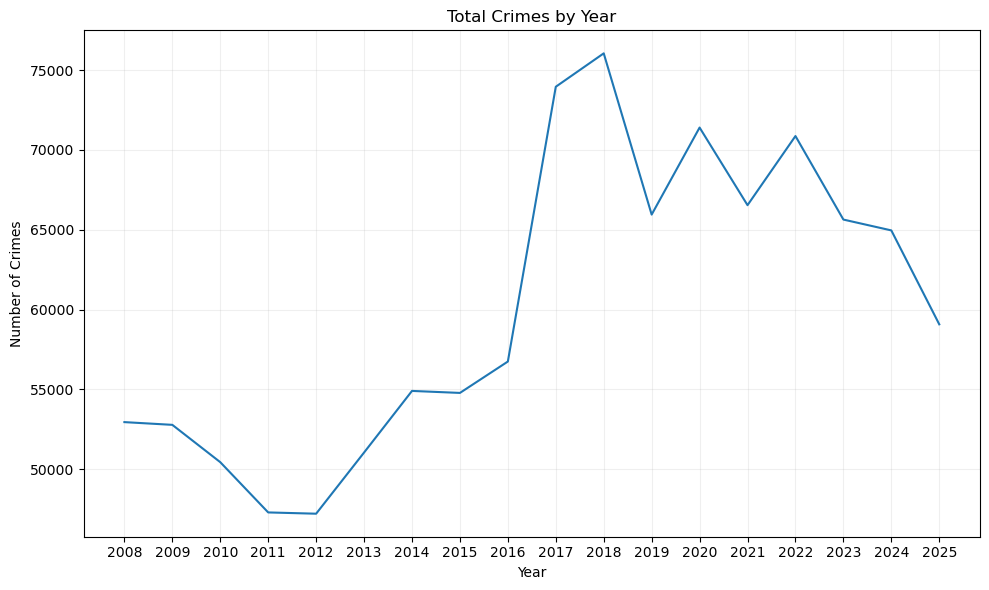

In [43]:
# Remove partial year (2026)
df_year_filtered = df[df['Year'] < 2026]

# Plot total crimes over the years
plt.figure(figsize=(10, 6))

crimes_by_year = df_year_filtered.groupby('Year').size()
crimes_by_year.plot(kind='line')

plt.title('Total Crimes by Year')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.xticks(crimes_by_year.index)
plt.grid(True, alpha=0.2)
plt.tight_layout()

This plot shows the total number of reported crime incidents per year in the dataset. Crime levels declined slightly between 2008 and 2012 before increasing steadily through the mid-2010s. The number of reported incidents peaked around 2017–2018, after which crime levels fluctuated but generally trended slightly downward in the early 2020s.

To avoid distortion from incomplete data, the most recent partial year was excluded from this visualization. Examining yearly trends provides useful context for understanding long-term changes in crime patterns within the dataset.

**3.1.3 Crime Types over Time**

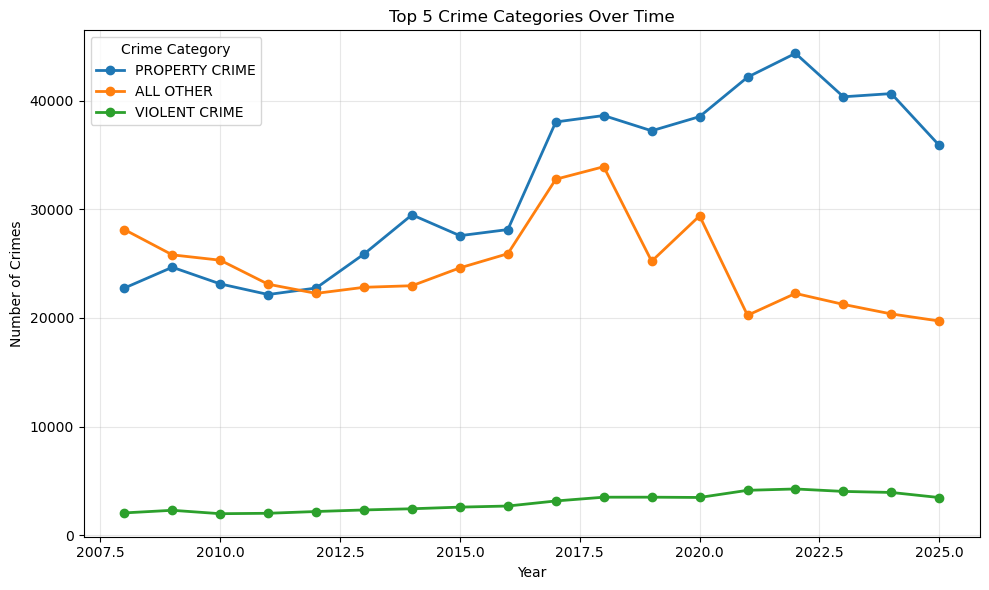

In [44]:
# Remove incomplete year
df_filtered = df[df['Year'] < 2026]

# Get top crime categories
top_crimes = df_filtered['Offense Category'].value_counts().head(5).index

df_top = df_filtered[df_filtered['Offense Category'].isin(top_crimes)]

# Group by year and crime type
crimes_by_type = df_top.groupby(['Year', 'Offense Category']).size().reset_index(name='Count')

plt.figure(figsize=(10, 6))

for crime in top_crimes:
    data = crimes_by_type[crimes_by_type['Offense Category'] == crime]
    plt.plot(data['Year'], data['Count'], marker='o', linewidth=2, label=crime)

plt.title('Top 5 Crime Categories Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.legend(title='Crime Category', loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

This line chart shows trends in three crime categories over time: **All Other**, **Property Crime**, and **Violent Crime**.

- **Property Crime** generally increases from around 2008, peaking around 2022, then begins to decline.
- **All Other crimes** fluctuate, rising to a peak around 2017–2018 before declining in later years.
- **Violent Crime** shows a gradual upward trend over time, with a slight peak around 2022–2023.

Overall, the chart highlights a shift where property crime becomes the dominant category over time, while violent crime steadily increases but remains significantly lower than the others.

**3.1.4 Crime Count by Month**

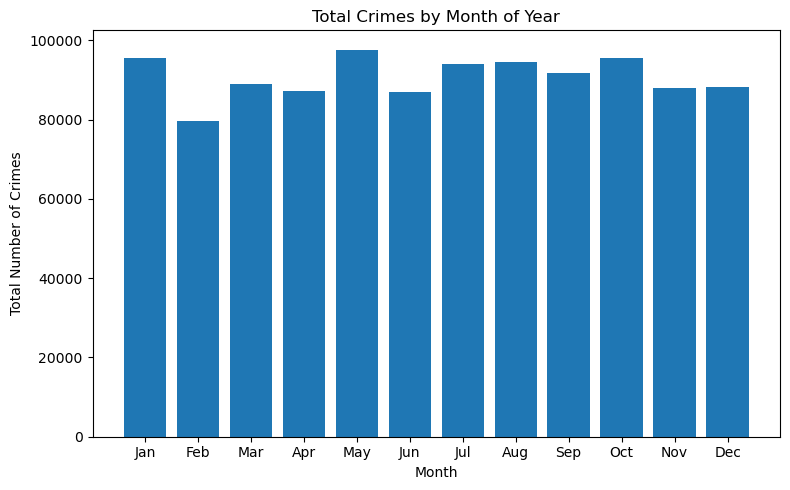

In [45]:
# Monthly trends (aggregated across all years)
plt.figure(figsize=(8, 5))
    
monthly_counts = df.groupby('Month').size()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.bar(monthly_counts.index, monthly_counts.values)
plt.title('Total Crimes by Month of Year')
plt.xlabel('Month')
plt.ylabel('Total Number of Crimes')
plt.xticks(range(1, 13), months)
plt.tight_layout()

This visualization shows the distribution of crime incidents aggregated by month across all years in the dataset. Crime counts remain relatively consistent throughout the year, with only moderate variation between months.

While certain months such as May and the summer period (June–August) show slightly higher totals, the overall differences are not substantial. This suggests that seasonality exists but is not a dominant driver of crime frequency in this dataset.

Because the variation across months is relatively small, the `Month` feature is retained as a temporal attribute but is not expected to be a primary factor in distinguishing crime patterns during clustering.

**3.1.5 Crime Count by Day of Week and Hour of Day**

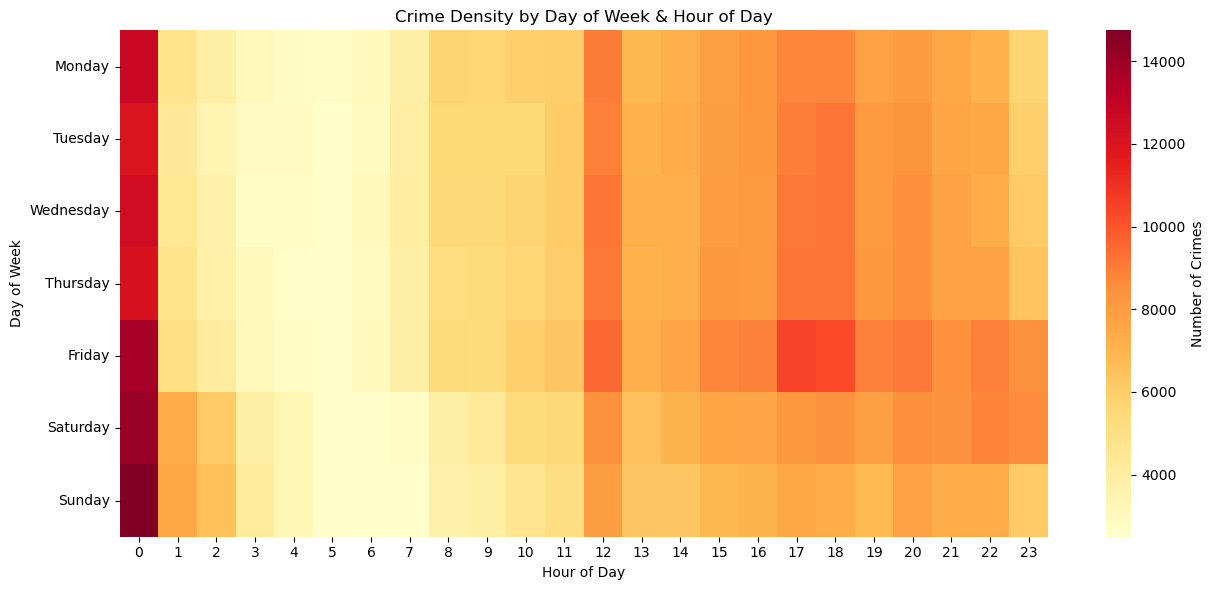

In [46]:
# Plot heatmap of crimes by day of week and hour of day
density_data = df.groupby(['DayOfWeek', 'Hour']).size().reset_index(name='Count')
counts = density_data.pivot(index='DayOfWeek', columns='Hour', values='Count')

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(13, 6))
sns.heatmap(counts, cmap='YlOrRd', annot=False, fmt='g', cbar_kws={'label': 'Number of Crimes'})
plt.title('Crime Density by Day of Week & Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.yticks(ticks=np.arange(7) + 0.5, labels=days, rotation=0)
plt.tight_layout()

The heatmap illustrates how crime incidents vary across hours of the day and days of the week. Crime activity is generally lower during the early morning hours (approximately 3–6 AM) and increases during the afternoon and evening.

Additionally, higher crime counts appear during late hours on Friday and Saturday compared to weekdays, indicating potential differences between weekday and weekend patterns.

These observations suggest that temporal characteristics such as hour of day and day of week capture meaningful structure in the data. Based on this pattern, temporal features were later engineered, including indicators for the hour of occurrence, day of week, and whether an incident occurred on a weekend.

### 3.2 Where are safety concerns concentrated?

**3.2.1 Crime Count by Neighborhood**

In [47]:
# Drop missing values in the 'Neighborhood' column
neighborhood_counts = (
    df["Neighborhood"]
    .dropna()
    .value_counts()
)

neighborhood_counts.head(15)

Neighborhood
DOWNTOWN COMMERCIAL                 42393
CAPITOL HILL                        39163
QUEEN ANNE                          33990
NORTHGATE                           33914
SLU/CASCADE                         27969
UNIVERSITY                          26181
ROOSEVELT/RAVENNA                   25040
BALLARD SOUTH                       23577
FIRST HILL                          19915
CHINATOWN/INTERNATIONAL DISTRICT    17895
LAKECITY                            15885
CENTRAL AREA/SQUIRE PARK            15637
BELLTOWN                            15331
SANDPOINT                           14252
GREENWOOD                           12882
Name: count, dtype: int64

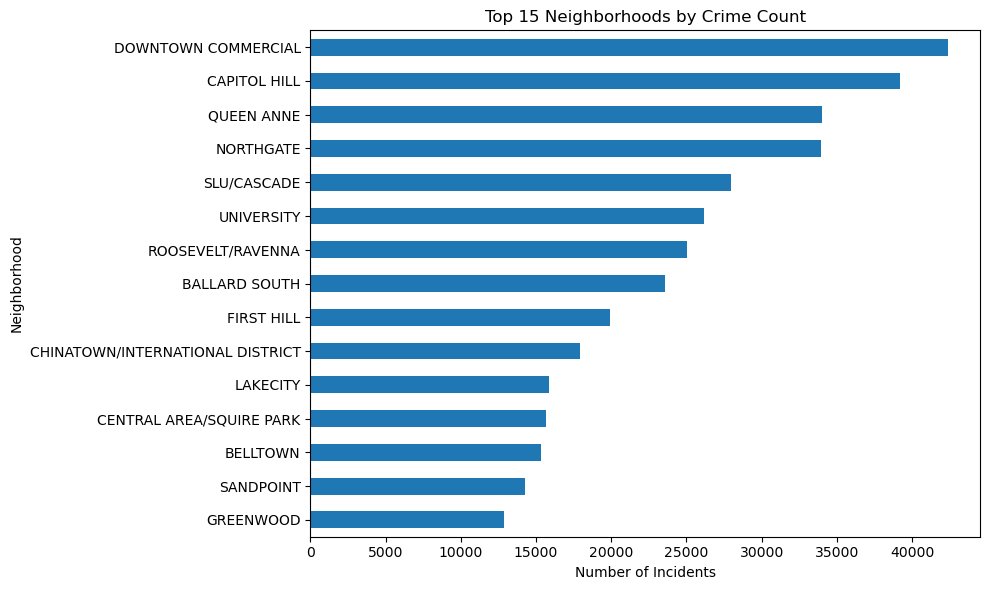

In [48]:

# Visualize the top 15 neighborhoods by crime count
top_15 = neighborhood_counts.head(15)
plt.figure(figsize=(10, 6))
top_15.sort_values().plot(kind="barh")
plt.xlabel("Number of Incidents")
plt.ylabel("Neighborhood")
plt.title("Top 15 Neighborhoods by Crime Count")
plt.tight_layout()
plt.show()

Crime incidents are highly concentrated in central and mixed-use neighborhoods. Downtown Commercial exhibits the highest number of reported incidents, followed closely by Capitol Hill and Northgate. 

This pattern suggests spatial clustering in high-density commercial and entertainment areas, where population flow and activity levels are elevated. Peripheral and predominantly residential neighborhoods show comparatively lower incident frequencies.

**3.2.2 Crime Count by Precinct**

In [49]:
# Drop missing values in the 'Precinct' column
precinct_counts = (
    df["Precinct"]
    .dropna()
    .value_counts()
)

precinct_counts

Precinct
North        337197
West         319264
East         179537
South        150379
Southwest     99816
OOJ            1735
Name: count, dtype: int64

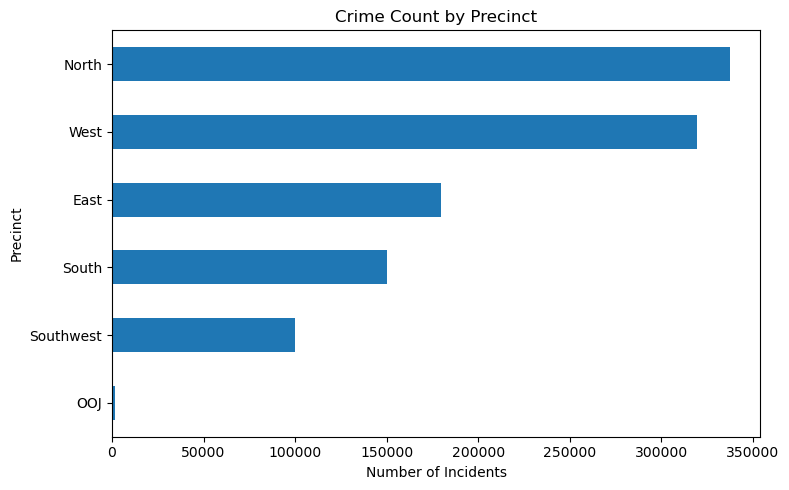

In [50]:
# Visualize crime count by precinct
plt.figure(figsize=(8, 5))
precinct_counts.sort_values().plot(kind="barh")
plt.xlabel("Number of Incidents")
plt.ylabel("Precinct")
plt.title("Crime Count by Precinct")
plt.tight_layout()
plt.show()

Crime distribution across precincts is uneven, with the North and West precincts reporting the highest number of incidents. These precincts encompass central and high-density areas of the city, which likely contributes to elevated crime frequency.

The East and South precincts exhibit moderate incident counts, while the Southwest precinct reports comparatively fewer incidents. The "OOJ" category represents a minimal number of cases and likely corresponds to administrative or out-of-jurisdiction records rather than a physical patrol area.

Overall, the results reinforce the presence of spatial clustering at a broader administrative level, consistent with the neighborhood-level patterns observed earlier.

**3.1.3 Spatial Density Using Geographical Coordinates**

In [51]:
# Create a sample of the data for spatial visualization 
sample_size = 200000
df_sample = df.dropna(subset=["Latitude", "Longitude"]).sample(
    n=sample_size, random_state=42
)

len(df_sample)

200000

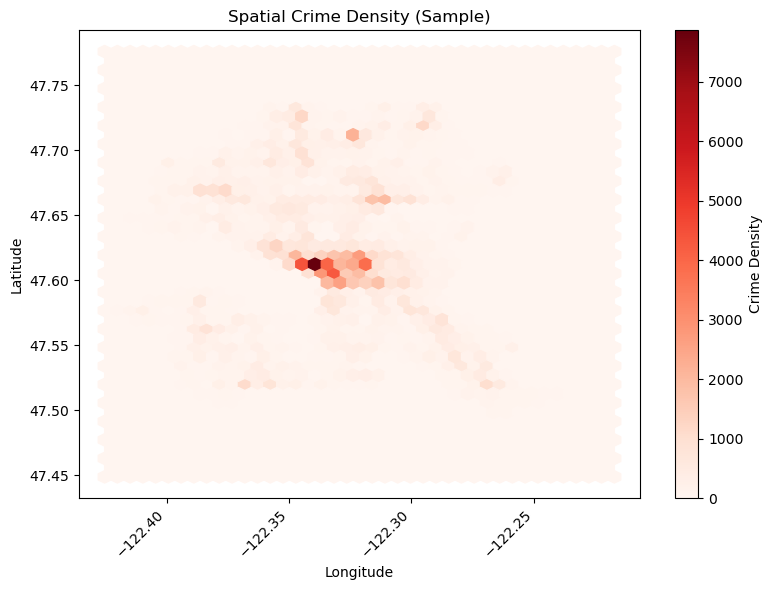

In [52]:
# Visualize spatial crime density using a hexbin plot
plt.figure(figsize=(8, 6))
plt.hexbin(
    df_sample["Longitude"],
    df_sample["Latitude"],
    gridsize=40,
    cmap="Reds"
)
plt.colorbar(label="Crime Density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Crime Density (Sample)")
plt.xticks(rotation=45, ha="right")   # Rotate x-axis labels
plt.tight_layout()
plt.show()

The spatial density visualization using a reduced grid size (gridsize=40) provides a clearer view of geographic concentration patterns. Crime incidents are visibly clustered in central areas of the city, with density decreasing toward peripheral regions.

Increasing the sample size to 200,000 observations did not materially alter the observed spatial structure, indicating that the clustering pattern is stable and not an artifact of sampling variation.

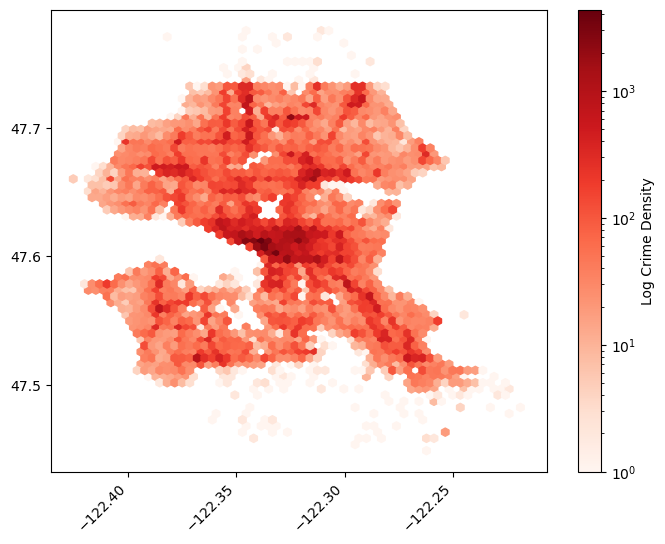

In [53]:
# Visualize spatial crime density using a hexbin plot with logarithmic color scaling
plt.figure(figsize=(8, 6))
plt.hexbin(
    df_sample["Longitude"],
    df_sample["Latitude"],
    gridsize=60,
    bins="log",
    cmap="Reds"
)

plt.xticks(rotation=45, ha="right")
plt.locator_params(axis="x", nbins=6)
plt.locator_params(axis="y", nbins=6)
plt.colorbar(label="Log Crime Density")

The log-scaled density visualization provides a clearer representation of spatial distribution by reducing the dominance of extreme hotspot values. While downtown remains the highest-density region, additional mid-density clusters become visible throughout adjacent neighborhoods.

This confirms that crime concentration follows a central-core pattern, with multiple secondary clusters radiating outward rather than a single isolated hotspot.

### 3.3 What types of incidents matter most?

In [54]:
# Unique value counts for crime category columns
crime_cat_cols = [
    "Offense Category",
    "Offense Sub Category",
    "NIBRS Crime Against Category"
]

cardinality_summary = pd.DataFrame({
    "Unique Values": [df[col].nunique() for col in crime_cat_cols]
}, index=crime_cat_cols)

cardinality_summary

,Unique Values
Offense Category,3
Offense Sub Category,27
NIBRS Crime Against Category,4


**3.3.1 Broad Offense Category Distribution**

In [55]:
# Distribution of "Offense Category"
crime_cat_counts = df["Offense Category"].value_counts()

crime_cat_counts

Offense Category
PROPERTY CRIME    585689
ALL OTHER         447907
VIOLENT CRIME      54548
Name: count, dtype: int64

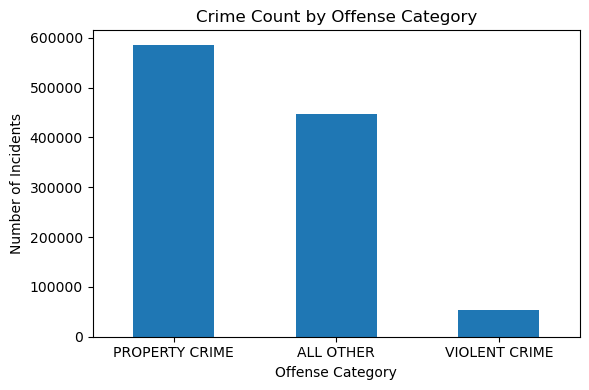

In [56]:
# Visualize crime count by offense category
plt.figure(figsize=(6,4))
crime_cat_counts.plot(kind="bar")
plt.ylabel("Number of Incidents")
plt.title("Crime Count by Offense Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The dataset is heavily concentrated in two broad categories: `ALL OTHER` and `PROPERTY CRIME`, which together account for the vast majority of reported incidents. `VIOLENT CRIME` represents a substantially smaller portion of total offenses.

This imbalance indicates that crime incidents are not uniformly distributed across high-level classifications. The dominance of non-violent and property-related offenses suggests that clustering results may be influenced primarily by these categories unless additional granularity is introduced.

Because broad categories exhibit limited variability (only three groups), more detailed classification through `Offense Sub Category` is necessary to capture meaningful differentiation in crime patterns.

**3.3.2 NIBRS Crime Against Category Distribution**

In [57]:
# Distribution of "NIBRS Crime Against Category"
nibrs_counts = df["NIBRS Crime Against Category"].value_counts()

nibrs_counts

NIBRS Crime Against Category
PROPERTY    778712
ANY         141304
PERSON      106295
SOCIETY      60586
Name: count, dtype: int64

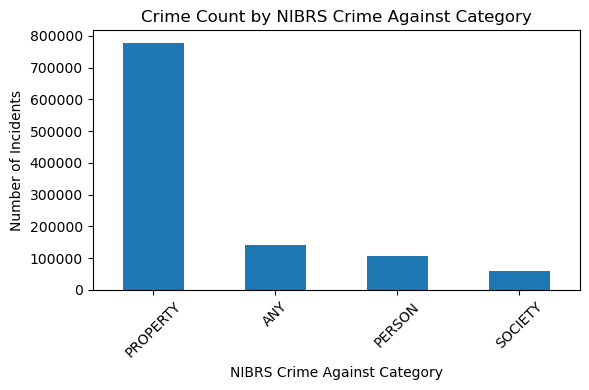

In [58]:
# Visualize crime count by NIBRS Crime Against Category
plt.figure(figsize=(6,4))
nibrs_counts.plot(kind="bar")
plt.ylabel("Number of Incidents")
plt.title("Crime Count by NIBRS Crime Against Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The `NIBRS Crime Against Category` distribution shows a strong dominance of `PROPERTY` crimes, which account for the majority of reported incidents. `PERSON` and `SOCIETY` crimes occur at substantially lower frequencies, while `ANY` represents a smaller portion of records.

This imbalance indicates that crime incidents are not evenly distributed across high-level classifications. The dominance of property-related offenses suggests that spatial and temporal clustering patterns may be heavily influenced by this category.

Although this variable provides useful high-level structure, it represents a broader abstraction of `Offense Sub Category`. Therefore, the more granular subcategory variable was selected for encoding in subsequent feature engineering.

**3.3.3 Crime Subcategory Distribution**

In [59]:
# Distribution of "Offense Sub Category"
subcat_counts = df["Offense Sub Category"].value_counts()

subcat_counts.head(15)

Offense Sub Category
LARCENY-THEFT                                            394832
ALL OTHER                                                141304
BURGLARY                                                 112304
PROPERTY OFFENSES (INCLUDES STOLEN, DESTRUCTION)          99189
MOTOR VEHICLE THEFT                                       76519
ASSAULT OFFENSES                                          76183
EXTORTION/FRAUD/FORGERY/BRIBERY (INCLUDES BAD CHECKS)     68683
AGGRAVATED ASSAULT                                        29346
NARCOTIC VIOLATIONS (INCLUDES DRUG EQUIP.)                26273
ROBBERY                                                   25151
DUI                                                       18804
WEAPON LAW VIOLATION                                      10211
DISORDERLY CONDUCT & VAGRANCY VIOLATIONS                   2408
TRESPASS                                                   2391
ARSON                                                      2034
Name: count, dtype:

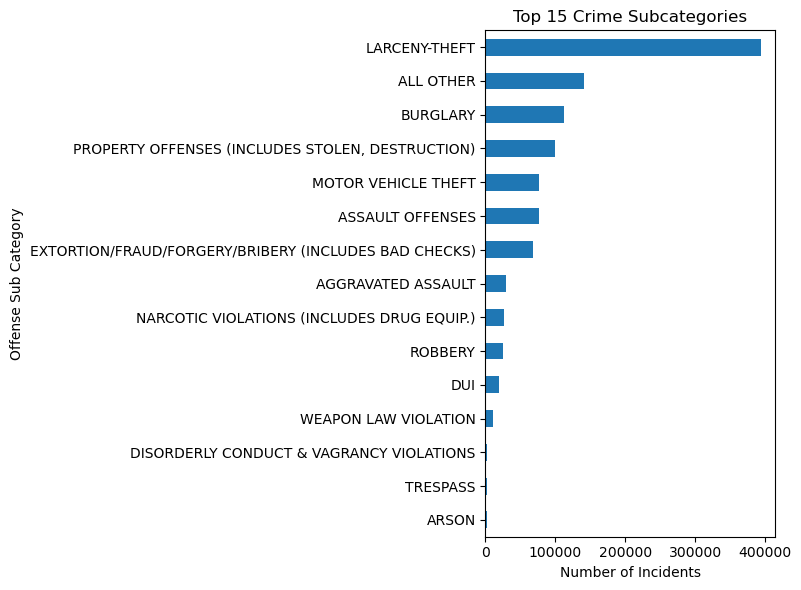

In [60]:
# Visualize the top 15 offense subcategories by crime count
plt.figure(figsize=(8,6))
subcat_counts.head(15).sort_values().plot(kind="barh")
plt.xlabel("Number of Incidents")
plt.title("Top 15 Crime Subcategories")
plt.tight_layout()
plt.show()

Subcategory-level analysis reveals substantial imbalance across offense types. `LARCENY-THEFT` overwhelmingly dominates the dataset, followed by categories such as `ALL OTHER`, `ASSAULT OFFENSES`, and `BURGLARY`.

A small number of subcategories account for a disproportionately large share of total incidents, while many others occur relatively infrequently. This imbalance is important for clustering, as dominant categories may heavily influence cluster formation.

Despite the skewed distribution, `Offense Sub Category` provides significantly more granular differentiation than broad offense categories and is therefore better suited for encoding and clustering analysis.

## 4. Feature Engineering

### 4.1 Temporal Features

In [61]:
# Extract temporal features from 'Offense Date'
df["Year"] = df["Offense Date"].dt.year
df["Month"] = df["Offense Date"].dt.month
df["DayOfWeek"] = df["Offense Date"].dt.dayofweek
df["Hour"] = df["Offense Date"].dt.hour

# Create a binary feature indicating whether the offense occurred on a weekend (Saturday=5, Sunday=6)
df["Is_Weekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

# Create a binary feature indicating whether the offense occurred at night (8 PM – 5 AM)
df["Is_Night"] = ((df["Hour"] >= 20) | (df["Hour"] <= 5)).astype(int)

Temporal features were previously extracted from the `Offense Date` variable during the exploratory analysis stage (Section 3.1.1). These features were retained for modeling and clustering because they capture meaningful temporal structure in crime incidents.

The temporal features used for modeling include:
- `Month` – Captures potential seasonal variation in crime patterns.
- `DayOfWeek` – Represents the day of the week (0–6) to identify weekday versus weekend patterns.
- `Hour` – Captures time-of-day effects in crime occurrence.
- `Is_Weekend` – Binary indicator derived from 
- `DayOfWeek` to simplify weekend pattern detection.
- `Is_Night` – Binary indicator derived from `Hour` representing nighttime hours (8 PM–5 AM), capturing differences between daytime and nighttime crime activity.

These engineered temporal variables allow clustering and modeling methods to detect patterns without relying directly on raw datetime values.

### 4.2 Spatial Features

Spatial information is represented using precise geographic coordinates (`Latitude` and `Longitude`). Because these coordinates already provide continuous spatial representation, no additional transformation was required at this stage.

These variables will be retained for clustering to capture geographic proximity and spatial structure within the dataset.

### 4.3 Crime Categorization

As observed in Section 3.3, `Offense Sub Category` contains 31 unique values and provides greater granularity compared to broader classifications such as `Offense Category` and `NIBRS` categorizations. Because the goal of this analysis is to identify meaningful crime patterns, this field was selected as the primary crime-type feature. More granular categories allow clustering algorithms to differentiate between specific incident types rather than grouping multiple crime behaviors into broad classes. This variable will be encoded during the modeling stage to prepare it for use in clustering.

### 4.4 Final Selected Features
`Latitude`  
`Longitude`  
`Month`  
`DayOfWeek`  
`Hour`  
`Is_Weekend`  
`Is_Night`  
`Offense Sub Category`

In [62]:
features = [
    "Latitude",
    "Longitude",
    "Month",
    "DayOfWeek",
    "Hour",
    "Is_Weekend",
    "Is_Night",
]

### 4.5 Feature Selection Rationale

For clustering purposes, a subset of engineered features was selected to balance interpretability while limiting unnecessary dimensionality.

Selected features include:

- `Latitude` and `Longitude` to capture spatial proximity between incidents.
- `Month`, `DayOfWeek`, `Hour`, `Is_Night`, and `Is_Weekend` to represent temporal patterns in crime occurrence.
- `Offense Sub Category` to provide detailed crime-type differentiation.

Broad crime classifications were excluded to avoid redundancy with the more granular subcategory variable. Administrative geographic labels (`Neighborhood`, `Precinct`, `Beat`, `Sector`) were also excluded because clustering algorithms rely on spatial distance, and these categorical boundaries could introduce artificial geographic divisions.

Identifier fields and raw datetime variables were removed because they do not provide meaningful structure for clustering.